In [1]:
!pip install yfinance requests fredapi matplotlib pandas

In [2]:
from google.colab import userdata
import yfinance as yf
import requests
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

# Load API keys from Colab Secrets
NEWS_API_KEY = userdata.get('NEWS_API_KEY')
FRED_API_KEY = userdata.get('FRED_API_KEY')

In [3]:
def get_stock_data(ticker="AAPL"):
    stock = yf.Ticker(ticker)
    df = stock.history(period="1mo")
    info = stock.info
    print(f"\n🏢 Company: {info.get('longName', ticker)}")
    print(f"💰 Current Price: ${info.get('currentPrice', 'N/A')}")
    print(f"📊 52W High: ${info.get('fiftyTwoWeekHigh', 'N/A')}")
    print(f"📉 52W Low: ${info.get('fiftyTwoWeekLow', 'N/A')}")
    return df

stock_df = get_stock_data("AAPL")
print(stock_df.tail())


🏢 Company: Apple Inc.
💰 Current Price: $252.89
📊 52W High: $288.62
📉 52W Low: $169.21
                                 Open        High         Low       Close  \
Date                                                                        
2026-03-20 00:00:00-04:00  247.979996  249.199997  246.000000  247.990005   
2026-03-23 00:00:00-04:00  253.970001  254.600006  250.279999  251.490005   
2026-03-24 00:00:00-04:00  250.350006  254.830002  249.550003  251.639999   
2026-03-25 00:00:00-04:00  254.100006  255.000000  251.600006  252.619995   
2026-03-26 00:00:00-04:00  251.994995  257.000000  250.774994  252.889999   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-03-20 00:00:00-04:00  88331100        0.0           0.0  
2026-03-23 00:00:00-04:00  40546100        0.0           0.0  
2026-03-24 00:00:00-04:00  45152300        0.0           0.0  
2026-03-25 00:00:00-04:00  28476700        0.0           0

In [4]:
def get_news(query="stock market"):
    url = f"https://newsapi.org/v2/everything?q={query}&sortBy=publishedAt&apiKey={NEWS_API_KEY}&pageSize=5"
    response = requests.get(url)
    data = response.json()

    if data["status"] != "ok":
        print("❌ News API error:", data.get("message"))
        return

    print(f"\n📰 Latest News for: '{query}'\n" + "="*50)
    for i, article in enumerate(data["articles"], 1):
        print(f"\n{i}. {article['title']}")
        print(f"   🔗 {article['url']}")
        print(f"   🕒 {article['publishedAt'][:10]}")

get_news("stock market")


📰 Latest News for: 'stock market'

1. Invitation to Aspo Plc’s Annual General Meeting 2026
   🔗 https://www.globenewswire.com/news-release/2026/03/26/3262774/0/en/Invitation-to-Aspo-Plc-s-Annual-General-Meeting-2026.html
   🕒 2026-03-26

2. KraneShares Launches California Carbon ETC (KCCA) on London Stock Exchange
   🔗 https://www.globenewswire.com/news-release/2026/03/26/3262777/0/en/KraneShares-Launches-California-Carbon-ETC-KCCA-on-London-Stock-Exchange.html
   🕒 2026-03-26

3. BASF Opens $11.6 Billion Chinese Site as Iran War Stokes Turmoil
   🔗 https://financialpost.com/pmn/business-pmn/basf-opens-11-6-billion-chinese-site-as-iran-war-stokes-turmoil
   🕒 2026-03-26

4. Never Build a Presentation Slide Deck Again Thanks to This AI
   🔗 https://www.geeky-gadgets.com/ai-presentations-prompts/
   🕒 2026-03-26

5. 10 Japanese Stocks Australian Investors Should Consider in 2026 for Diversification
   🔗 https://www.ibtimes.com.au/10-japanese-stocks-australian-investors-should-consider-2

In [5]:
def get_economic_data():
    fred = Fred(api_key=FRED_API_KEY)

    gdp = fred.get_series('GDP')
    inflation = fred.get_series('CPIAUCSL')
    unemployment = fred.get_series('UNRATE')

    print("\n🏦 Economic Indicators")
    print("="*50)
    print(f"📈 Latest GDP:          ${gdp.iloc[-1]:,.2f} Billion")
    print(f"💸 Latest CPI:          {inflation.iloc[-1]:.2f}")
    print(f"👷 Unemployment Rate:   {unemployment.iloc[-1]}%")

    return gdp, inflation, unemployment

gdp, inflation, unemployment = get_economic_data()


🏦 Economic Indicators
📈 Latest GDP:          $31,442.48 Billion
💸 Latest CPI:          327.46
👷 Unemployment Rate:   4.4%


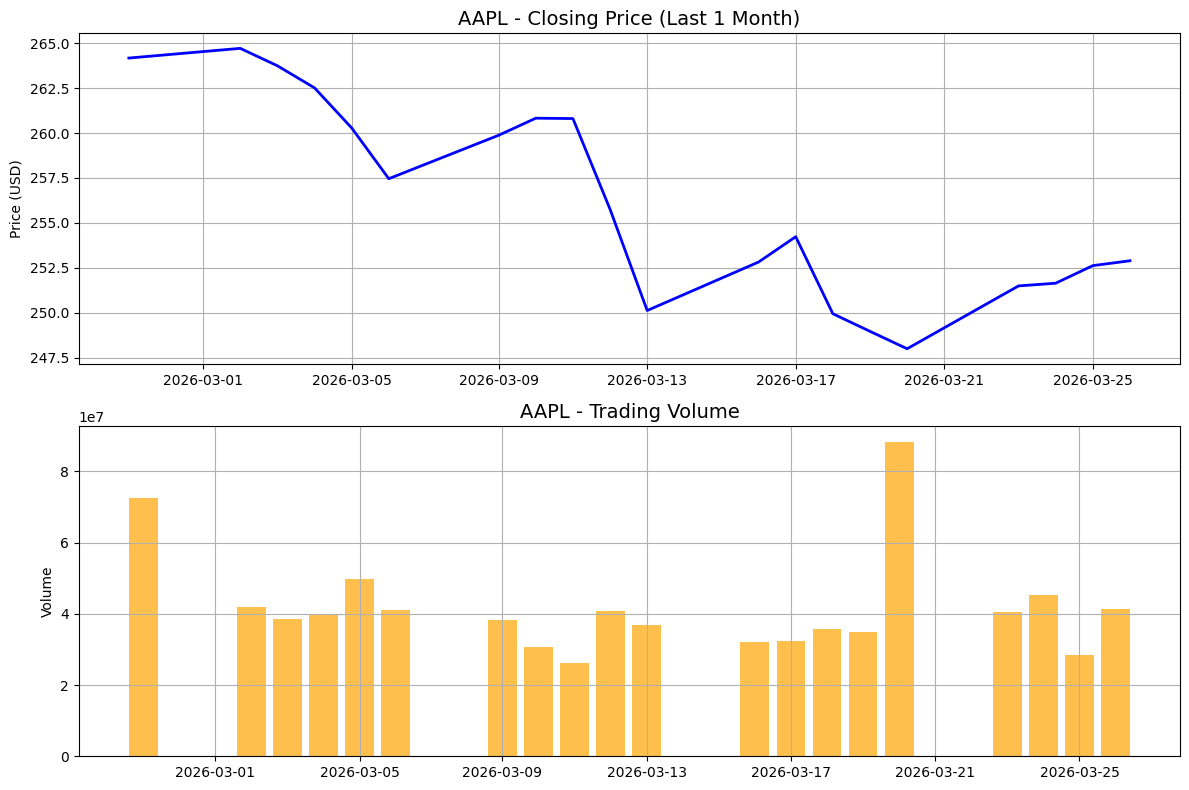

In [6]:
def plot_stock(df, ticker="AAPL"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Price chart
    axes[0].plot(df.index, df["Close"], color="blue", linewidth=2)
    axes[0].set_title(f"{ticker} - Closing Price (Last 1 Month)", fontsize=14)
    axes[0].set_ylabel("Price (USD)")
    axes[0].grid(True)

    # Volume chart
    axes[1].bar(df.index, df["Volume"], color="orange", alpha=0.7)
    axes[1].set_title(f"{ticker} - Trading Volume", fontsize=14)
    axes[1].set_ylabel("Volume")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_stock(stock_df, "AAPL")

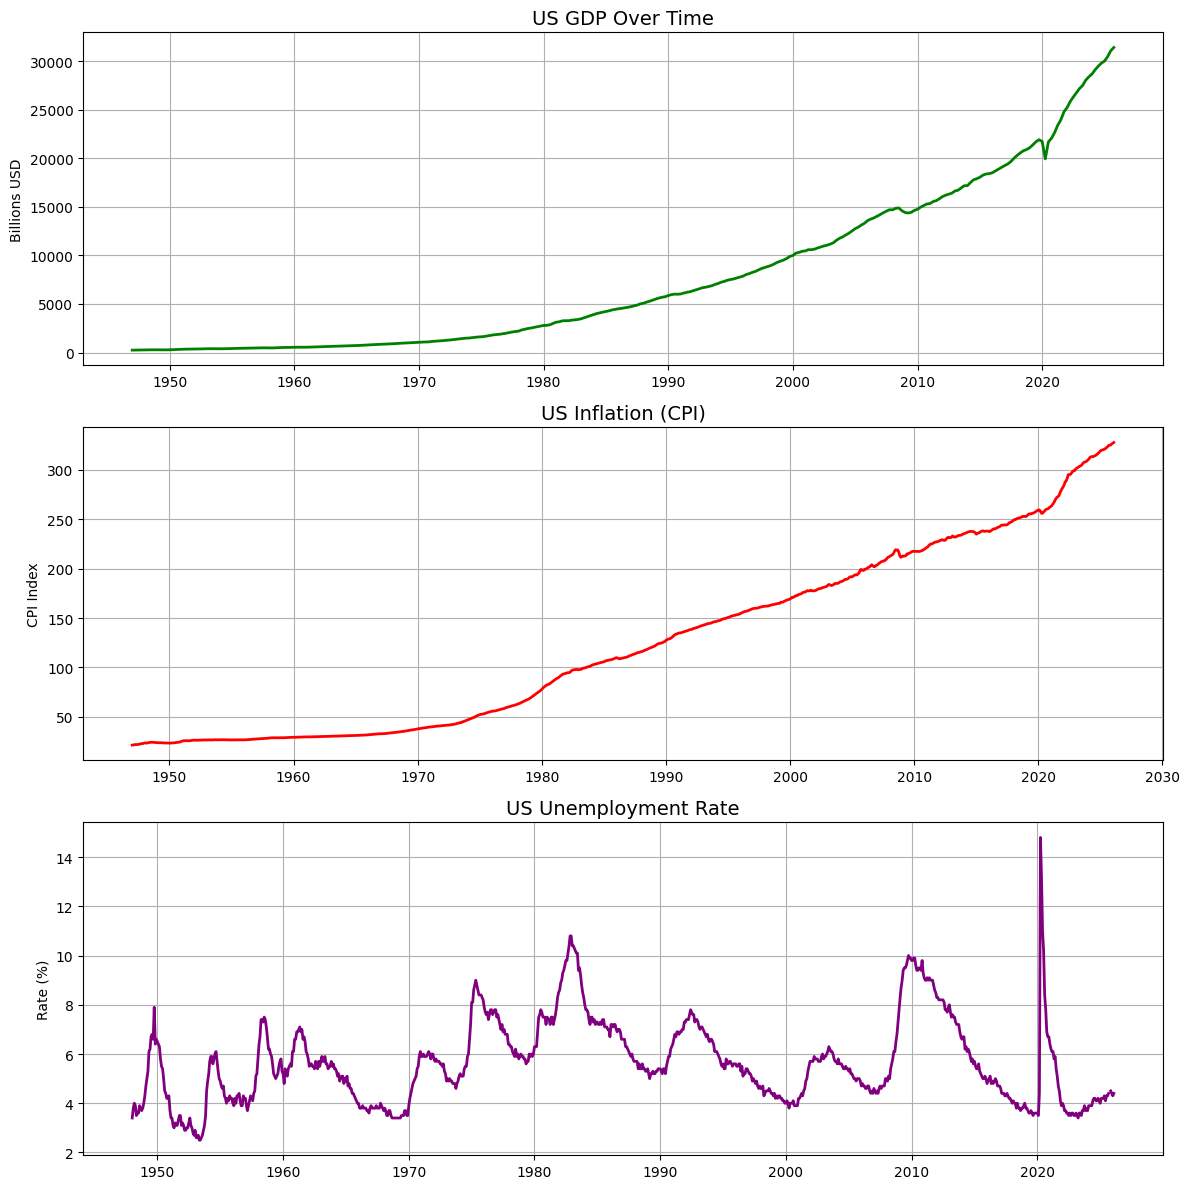

In [7]:
def plot_economic(gdp, inflation, unemployment):
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    axes[0].plot(gdp.index, gdp.values, color="green", linewidth=2)
    axes[0].set_title("US GDP Over Time", fontsize=14)
    axes[0].set_ylabel("Billions USD")
    axes[0].grid(True)

    axes[1].plot(inflation.index, inflation.values, color="red", linewidth=2)
    axes[1].set_title("US Inflation (CPI)", fontsize=14)
    axes[1].set_ylabel("CPI Index")
    axes[1].grid(True)

    axes[2].plot(unemployment.index, unemployment.values, color="purple", linewidth=2)
    axes[2].set_title("US Unemployment Rate", fontsize=14)
    axes[2].set_ylabel("Rate (%)")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_economic(gdp, inflation, unemployment)

In [10]:
def run_dashboard(ticker="TSLA", news_query="stock market"):
    print("="*60)
    print(f"   📊 FINANCIAL DASHBOARD — {ticker}")
    print("="*60)

    # Stock
    stock_df = get_stock_data(ticker)
    plot_stock(stock_df, ticker)

    # News
    get_news(news_query)

    # Economy
    gdp, inflation, unemployment = get_economic_data()
    plot_economic(gdp, inflation, unemployment)

    print("\n✅ Dashboard Complete!")

Enter stock ticker (e.g. AAPL, TSLA, INFY):TSLA
Enter news topic:Tesla stock
   📊 FINANCIAL DASHBOARD — TSLA

🏢 Company: Tesla, Inc.
💰 Current Price: $372.11
📊 52W High: $498.83
📉 52W Low: $214.25


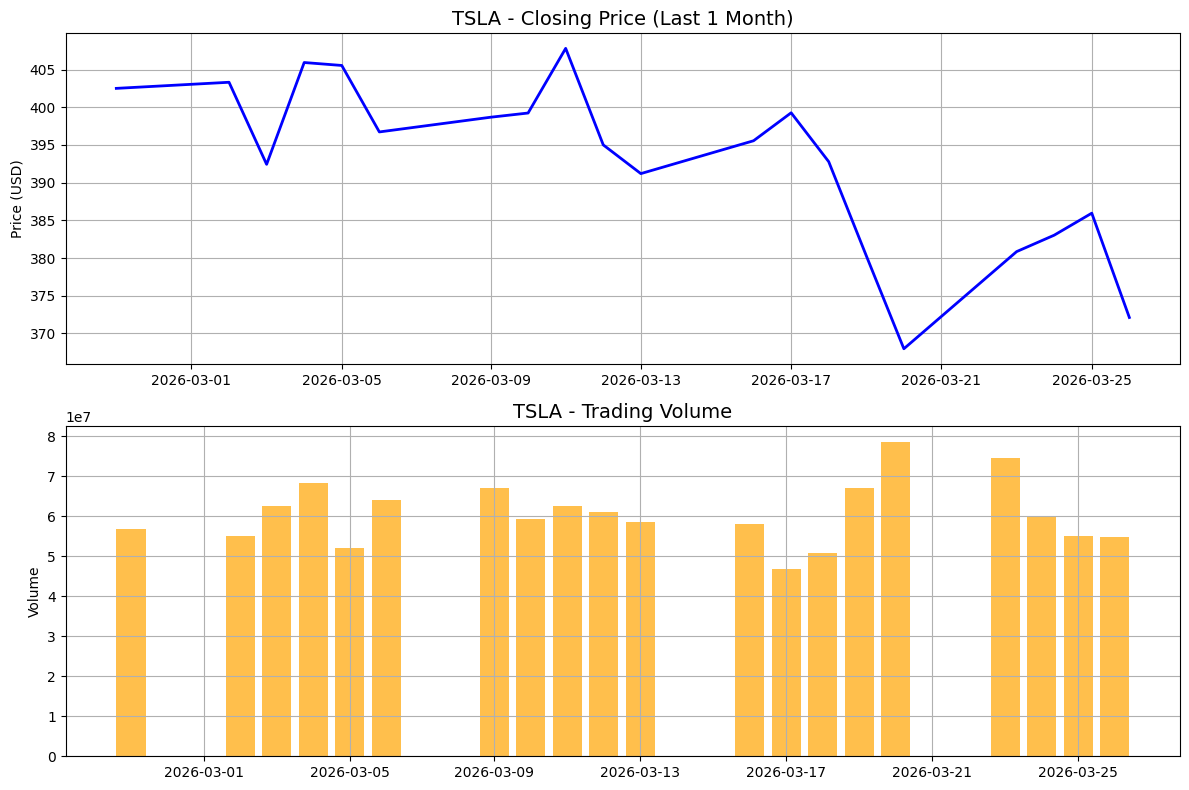


📰 Latest News for: 'Tesla stock'

1. Elon Musk calls for Delaware judge to recuse herself in lawsuits, alleging bias
   🔗 https://www.cnbc.com/2026/03/25/elon-musk-calls-for-delaware-judge-to-recuse-in-cases-alleging-bias.html
   🕒 2026-03-25

2. Elon Musk picks flood-prone New Orleans as possible site for next underground tunnel: ‘What could go wrong?’
   🔗 https://nypost.com/2026/03/25/us-news/elon-musk-picks-flood-prone-new-orleans-for-next-underground-tunnel/
   🕒 2026-03-25

3. Franklin Templeton, Ondo to launch tokenized ETFs with 24/7 trading via crypto wallets
   🔗 https://cointelegraph.com/news/franklin-templeton-ondo-to-launch-tokenized-etfs-with-24-7-trading-via-crypto-wallets
   🕒 2026-03-25

4. Elon Musk Just Announced a ‘Herculean Task’ for Tesla. Can TSLA Stock Survive and Thrive?
   🔗 https://consent.yahoo.com/v2/collectConsent?sessionId=1_cc-session_02c06d85-d54f-4d0f-9a73-387cf698f894
   🕒 2026-03-25

🏦 Economic Indicators
📈 Latest GDP:          $31,442.48 Billion
💸 

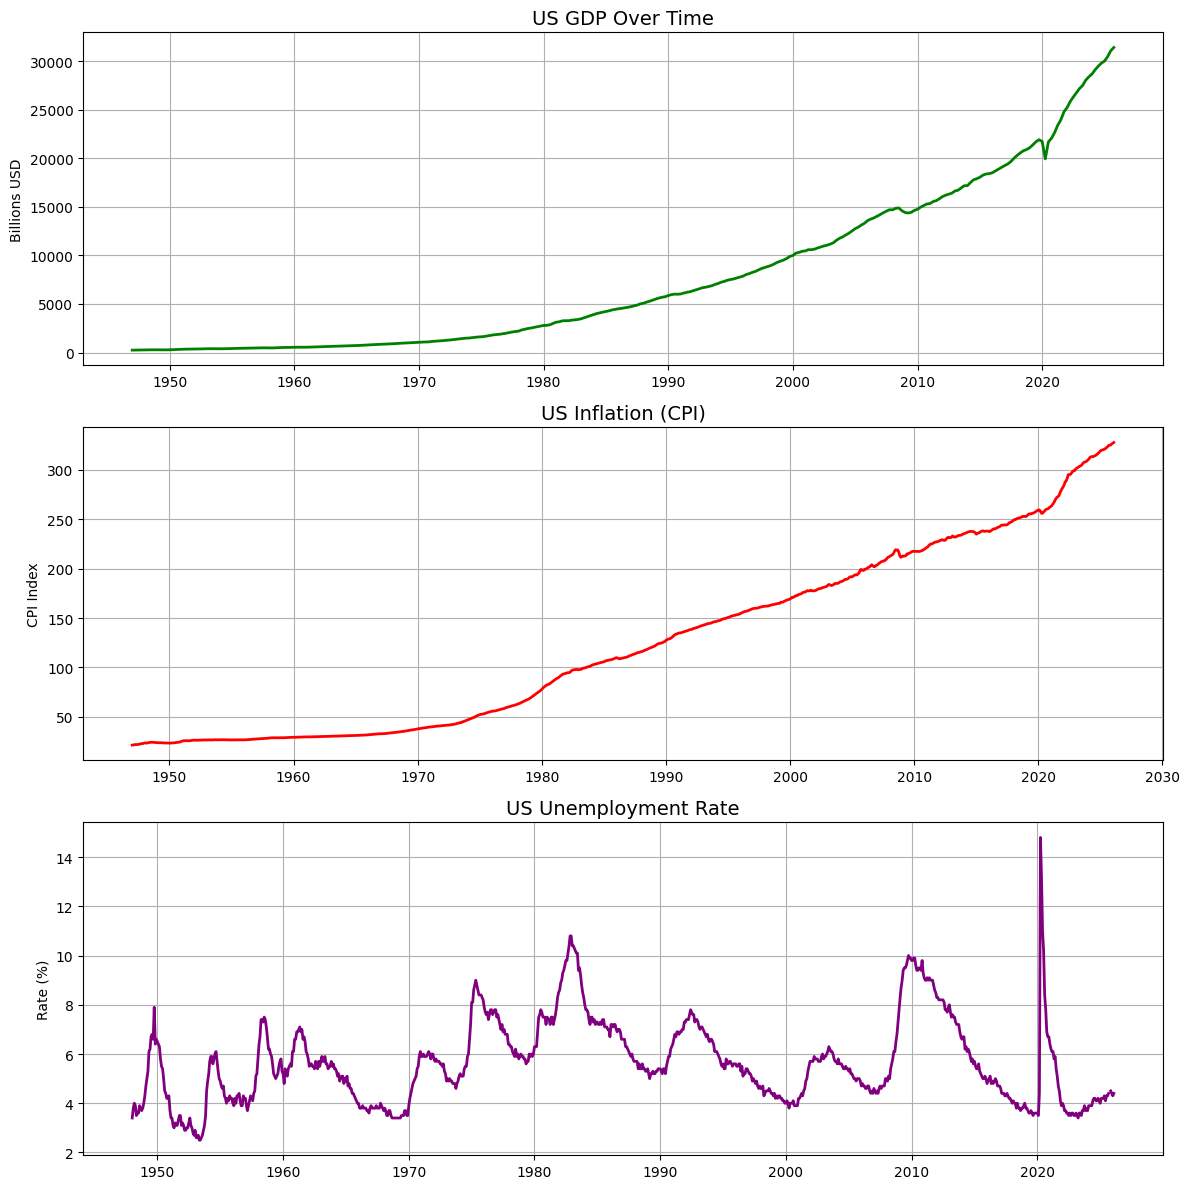


✅ Dashboard Complete!


In [11]:
ticker = input("Enter stock ticker (e.g. AAPL, TSLA, INFY):")
news_query = input("Enter news topic:")
run_dashboard(ticker=ticker, news_query=news_query)